# Exploratory Data Analysis (EDA) Profundo - Dataset Curves

## Parte 1: Estructura General y Metadatos

Este notebook realiza un analisis exhaustivo del dataset de curvas, explorando cada aspecto de los datos contenidos en las carpetas `pixel_curves/` y `target/`.

---

### Tabla de Contenidos
1. Resumen Ejecutivo del Dataset
2. Estructura de Directorios y Archivos
3. Analisis de Nomenclatura de Archivos
4. Formato de Datos
5. Estadisticas de Archivos (tamanos, lineas)
6. Verificacion de Integridad

In [1]:
import os
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import defaultdict
import re
from pathlib import Path

# Configuracion de visualizacion
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = [12, 6]
plt.rcParams['font.size'] = 10
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)

# Rutas base
BASE_PATH = Path('..')
PIXEL_CURVES_PATH = BASE_PATH / 'datos' / 'pixel_curves'
TARGET_PATH = BASE_PATH / 'datos' / 'target'

print("Configuracion cargada correctamente")

Configuracion cargada correctamente


---
## 1. Resumen Ejecutivo del Dataset

### Descripcion General

Este dataset contiene **curvas parametricas** representadas de dos formas diferentes:

1. **`target/`**: Curvas de alta precision con coordenadas continuas (valores flotantes)
2. **`pixel_curves/`**: Versiones discretizadas de las mismas curvas a diferentes resoluciones

### Proposito Inferido del Dataset
El dataset parece estar disenado para:
- Entrenamiento de modelos de reconstruccion de curvas
- Analisis de metodos de interpolacion/suavizado
- Estudio de discretizacion de curvas parametricas
- Posible aplicacion en vision por computadora o procesamiento de imagenes

In [2]:
# Contar archivos en cada carpeta
pixel_files = list(PIXEL_CURVES_PATH.glob('*.txt'))
target_files = list(TARGET_PATH.glob('*.txt'))

print("=" * 60)
print("RESUMEN GENERAL DEL DATASET")
print("=" * 60)
print(f"\nTotal de archivos en pixel_curves/: {len(pixel_files):,}")
print(f"Total de archivos en target/:        {len(target_files):,}")
print(f"Total de archivos en el dataset:     {len(pixel_files) + len(target_files):,}")
print(f"\nRelacion pixel_curves/target:        {len(pixel_files)/len(target_files):.1f}x")

RESUMEN GENERAL DEL DATASET

Total de archivos en pixel_curves/: 2,500
Total de archivos en target/:        500
Total de archivos en el dataset:     3,000

Relacion pixel_curves/target:        5.0x


---
## 2. Estructura de Directorios y Archivos

In [3]:
# Analisis de estructura de nombres de archivos
print("ESTRUCTURA DE CARPETA pixel_curves/")
print("-" * 50)

# Extraer patrones de nombres
pixel_pattern = re.compile(r'curve_(\d+)_X(\d+)\.txt')

curve_ids_pixel = set()
x_values = set()

for f in pixel_files:
    match = pixel_pattern.match(f.name)
    if match:
        curve_ids_pixel.add(int(match.group(1)))
        x_values.add(int(match.group(2)))

print(f"\nPatron de nomenclatura: curve_XXXX_XYY.txt")
print(f"  - XXXX: ID de curva (4 digitos con padding de ceros)")
print(f"  - YY: Parametro X (factor de escala/resolucion)")
print(f"\nIDs de curvas encontrados: {min(curve_ids_pixel):04d} a {max(curve_ids_pixel):04d}")
print(f"Total de curvas unicas: {len(curve_ids_pixel)}")
print(f"\nValores de X encontrados: {sorted(x_values)}")
print(f"Total de variantes por curva: {len(x_values)}")

ESTRUCTURA DE CARPETA pixel_curves/
--------------------------------------------------

Patron de nomenclatura: curve_XXXX_XYY.txt
  - XXXX: ID de curva (4 digitos con padding de ceros)
  - YY: Parametro X (factor de escala/resolucion)

IDs de curvas encontrados: 0001 a 0500
Total de curvas unicas: 500

Valores de X encontrados: [10, 15, 18, 21, 25]
Total de variantes por curva: 5


In [4]:
print("\nESTRUCTURA DE CARPETA target/")
print("-" * 50)

target_pattern = re.compile(r'curve_(\d+)\.txt')
curve_ids_target = set()

for f in target_files:
    match = target_pattern.match(f.name)
    if match:
        curve_ids_target.add(int(match.group(1)))

print(f"\nPatron de nomenclatura: curve_XXXX.txt")
print(f"  - XXXX: ID de curva (4 digitos con padding de ceros)")
print(f"\nIDs de curvas encontrados: {min(curve_ids_target):04d} a {max(curve_ids_target):04d}")
print(f"Total de curvas unicas: {len(curve_ids_target)}")


ESTRUCTURA DE CARPETA target/
--------------------------------------------------

Patron de nomenclatura: curve_XXXX.txt
  - XXXX: ID de curva (4 digitos con padding de ceros)

IDs de curvas encontrados: 0001 a 0500
Total de curvas unicas: 500


In [5]:
# Verificar correspondencia entre pixel_curves y target
print("\nVERIFICACION DE CORRESPONDENCIA")
print("-" * 50)

matching_ids = curve_ids_pixel.intersection(curve_ids_target)
only_in_pixel = curve_ids_pixel - curve_ids_target
only_in_target = curve_ids_target - curve_ids_pixel

print(f"\nCurvas con correspondencia completa: {len(matching_ids)}")
print(f"Curvas solo en pixel_curves: {len(only_in_pixel)}")
print(f"Curvas solo en target: {len(only_in_target)}")

if len(only_in_pixel) > 0:
    print(f"\n  IDs solo en pixel_curves: {sorted(only_in_pixel)[:10]}..." if len(only_in_pixel) > 10 else f"\n  IDs solo en pixel_curves: {sorted(only_in_pixel)}")
if len(only_in_target) > 0:
    print(f"  IDs solo en target: {sorted(only_in_target)[:10]}..." if len(only_in_target) > 10 else f"  IDs solo en target: {sorted(only_in_target)}")

if len(matching_ids) == len(curve_ids_pixel) == len(curve_ids_target):
    print("\n[OK] Todas las curvas tienen correspondencia 1:1 entre ambas carpetas")


VERIFICACION DE CORRESPONDENCIA
--------------------------------------------------

Curvas con correspondencia completa: 500
Curvas solo en pixel_curves: 0
Curvas solo en target: 0

[OK] Todas las curvas tienen correspondencia 1:1 entre ambas carpetas


---
## 3. Analisis de Nomenclatura de Archivos

In [6]:
print("ANALISIS DETALLADO DE NOMENCLATURA")
print("=" * 60)

# Verificar que todos los archivos siguen el patron esperado
invalid_pixel_files = []
invalid_target_files = []

for f in pixel_files:
    if not pixel_pattern.match(f.name):
        invalid_pixel_files.append(f.name)

for f in target_files:
    if not target_pattern.match(f.name):
        invalid_target_files.append(f.name)

print(f"\nArchivos en pixel_curves/ que no siguen el patron: {len(invalid_pixel_files)}")
if invalid_pixel_files:
    print(f"  Archivos invalidos: {invalid_pixel_files[:5]}")

print(f"\nArchivos en target/ que no siguen el patron: {len(invalid_target_files)}")
if invalid_target_files:
    print(f"  Archivos invalidos: {invalid_target_files[:5]}")

ANALISIS DETALLADO DE NOMENCLATURA

Archivos en pixel_curves/ que no siguen el patron: 0

Archivos en target/ que no siguen el patron: 0


In [7]:
# Verificar completitud de variantes X
print("\nVERIFICACION DE COMPLETITUD DE VARIANTES X")
print("-" * 50)

expected_x_values = sorted(x_values)
missing_variants = []

for curve_id in sorted(curve_ids_pixel):
    for x_val in expected_x_values:
        expected_file = PIXEL_CURVES_PATH / f"curve_{curve_id:04d}_X{x_val}.txt"
        if not expected_file.exists():
            missing_variants.append((curve_id, x_val))

print(f"\nVariantes esperadas por curva: {expected_x_values}")
print(f"Total esperado de archivos: {len(curve_ids_pixel)} curvas x {len(expected_x_values)} variantes = {len(curve_ids_pixel) * len(expected_x_values)}")
print(f"Total real de archivos: {len(pixel_files)}")
print(f"\nVariantes faltantes: {len(missing_variants)}")

if missing_variants:
    print(f"\nEjemplos de variantes faltantes:")
    for curve_id, x_val in missing_variants[:10]:
        print(f"  - curve_{curve_id:04d}_X{x_val}.txt")


VERIFICACION DE COMPLETITUD DE VARIANTES X
--------------------------------------------------

Variantes esperadas por curva: [10, 15, 18, 21, 25]
Total esperado de archivos: 500 curvas x 5 variantes = 2500
Total real de archivos: 2500

Variantes faltantes: 0


---
## 4. Formato de Datos

In [8]:
print("ANALISIS DE FORMATO DE DATOS")
print("=" * 60)

# Leer ejemplos de archivos target
print("\n--- FORMATO DE ARCHIVOS TARGET")
sample_target = TARGET_PATH / 'curve_0001.txt'
with open(sample_target, 'r') as f:
    lines = f.readlines()[:5]
    print(f"\nArchivo: {sample_target.name}")
    print("Primeras 5 lineas:")
    for i, line in enumerate(lines, 1):
        print(f"  Linea {i}: {line.strip()}")

# Analizar el formato
print("\nCaracteristicas del formato TARGET:")
print("  - Separador: coma (,)")
print("  - Columna 1: Coordenada X (float de alta precision ~15 decimales)")
print("  - Columna 2: Coordenada Y (float de alta precision ~15 decimales)")
print("  - Sin encabezado")
print("  - Sin indice de linea")

ANALISIS DE FORMATO DE DATOS

--- FORMATO DE ARCHIVOS TARGET

Archivo: curve_0001.txt
Primeras 5 lineas:
  Linea 1: 17.8846912101685,0.738732584117926
  Linea 2: 17.9297760393337,0.793520031524302
  Linea 3: 17.9748608069414,0.84830742577406
  Linea 4: 18.0199454514342,0.903094713710582
  Linea 5: 18.0650299112545,0.957881842177248

Caracteristicas del formato TARGET:
  - Separador: coma (,)
  - Columna 1: Coordenada X (float de alta precision ~15 decimales)
  - Columna 2: Coordenada Y (float de alta precision ~15 decimales)
  - Sin encabezado
  - Sin indice de linea


In [9]:
print("\n--- FORMATO DE ARCHIVOS PIXEL_CURVES")
for x_val in sorted(x_values):
    sample_pixel = PIXEL_CURVES_PATH / f'curve_0001_X{x_val}.txt'
    with open(sample_pixel, 'r') as f:
        lines = f.readlines()[:3]
    print(f"\nArchivo: {sample_pixel.name}")
    print("Primeras 3 lineas:")
    for line in lines:
        print(f"  {line.strip()}")

print("\nCaracteristicas del formato PIXEL_CURVES:")
print("  - Separador: espacio")
print("  - Columna 1: Coordenada X (entero)")
print("  - Columna 2: Coordenada Y (entero)")
print("  - Sin encabezado")
print("  - Valores discretizados (coordenadas de pixel)")


--- FORMATO DE ARCHIVOS PIXEL_CURVES

Archivo: curve_0001_X10.txt
Primeras 3 lineas:
  18 1
  19 2
  20 3

Archivo: curve_0001_X15.txt
Primeras 3 lineas:
  27 2
  28 2
  29 3

Archivo: curve_0001_X18.txt
Primeras 3 lineas:
  33 2
  34 3
  35 4

Archivo: curve_0001_X21.txt
Primeras 3 lineas:
  39 3
  40 4
  41 5

Archivo: curve_0001_X25.txt
Primeras 3 lineas:
  46 3
  47 4
  48 5

Caracteristicas del formato PIXEL_CURVES:
  - Separador: espacio
  - Columna 1: Coordenada X (entero)
  - Columna 2: Coordenada Y (entero)
  - Sin encabezado
  - Valores discretizados (coordenadas de pixel)


In [10]:
# Verificar consistencia del formato en multiples archivos
print("\nVERIFICACION DE CONSISTENCIA DE FORMATO")
print("-" * 50)

def check_file_format(filepath, expected_sep, expected_cols):
    """Verifica el formato de un archivo."""
    issues = []
    with open(filepath, 'r') as f:
        for i, line in enumerate(f, 1):
            line = line.strip()
            if not line:
                continue
            parts = line.split(expected_sep)
            if len(parts) != expected_cols:
                issues.append(f"Linea {i}: esperaba {expected_cols} columnas, encontro {len(parts)}")
            if len(issues) >= 3:
                break
    return issues

# Verificar muestra de archivos target
print("\nVerificando archivos target (muestra de 50):")
target_format_issues = 0
for f in list(target_files)[:50]:
    issues = check_file_format(f, ',', 2)
    if issues:
        target_format_issues += 1
        print(f"  Archivo {f.name}: {issues[0]}")
print(f"  Archivos con problemas de formato: {target_format_issues}/50")

# Verificar muestra de archivos pixel_curves
print("\nVerificando archivos pixel_curves (muestra de 50):")
pixel_format_issues = 0
for f in list(pixel_files)[:50]:
    issues = check_file_format(f, ' ', 2)
    if issues:
        pixel_format_issues += 1
        print(f"  Archivo {f.name}: {issues[0]}")
print(f"  Archivos con problemas de formato: {pixel_format_issues}/50")


VERIFICACION DE CONSISTENCIA DE FORMATO
--------------------------------------------------

Verificando archivos target (muestra de 50):
  Archivos con problemas de formato: 0/50

Verificando archivos pixel_curves (muestra de 50):
  Archivos con problemas de formato: 0/50


---
## 5. Estadisticas de Archivos

In [ ]:
print("ESTADISTICAS DE TAMANO DE ARCHIVOS")
print("=" * 60)

# Tamaños de archivos target
target_sizes = [f.stat().st_size for f in target_files]
target_sizes_kb = [s / 1024 for s in target_sizes]

print("\n--- ARCHIVOS TARGET")
print(f"Tamano total: {sum(target_sizes) / (1024*1024):.2f} MB")
print(f"Tamano promedio: {np.mean(target_sizes_kb):.2f} KB")
print(f"Tamano minimo: {min(target_sizes_kb):.2f} KB")
print(f"Tamano maximo: {max(target_sizes_kb):.2f} KB")
print(f"Desviacion estandar: {np.std(target_sizes_kb):.2f} KB")

ESTADISTICAS DE TAMANO DE ARCHIVOS

--- ARCHIVOS TARGET
Tamano total: 128.85 MB
Tamano promedio: 263.89 KB
Tamano minimo: 263.77 KB
Tamano maximo: 264.34 KB
Desviacion estandar: 0.05 KB


In [12]:
# Tamanos de archivos pixel_curves por variante X
print("\n--- ARCHIVOS PIXEL_CURVES")

pixel_sizes_by_x = defaultdict(list)
for f in pixel_files:
    match = pixel_pattern.match(f.name)
    if match:
        x_val = int(match.group(2))
        pixel_sizes_by_x[x_val].append(f.stat().st_size / 1024)

print(f"\nTamano total: {sum([f.stat().st_size for f in pixel_files]) / (1024*1024):.2f} MB")

print("\nEstadisticas por variante X:")
print("-" * 70)
print(f"{'X':>5} | {'Promedio (KB)':>14} | {'Min (KB)':>10} | {'Max (KB)':>10} | {'Std (KB)':>10}")
print("-" * 70)
for x_val in sorted(pixel_sizes_by_x.keys()):
    sizes = pixel_sizes_by_x[x_val]
    print(f"{x_val:>5} | {np.mean(sizes):>14.2f} | {min(sizes):>10.2f} | {max(sizes):>10.2f} | {np.std(sizes):>10.2f}")


--- ARCHIVOS PIXEL_CURVES

Tamano total: 6.24 MB

Estadisticas por variante X:
----------------------------------------------------------------------
    X |  Promedio (KB) |   Min (KB) |   Max (KB) |   Std (KB)
----------------------------------------------------------------------
   10 |           1.28 |       0.30 |       2.49 |       0.55
   15 |           2.07 |       0.45 |       4.06 |       0.88
   18 |           2.59 |       0.54 |       4.99 |       1.10
   21 |           3.10 |       0.67 |       5.89 |       1.30
   25 |           3.76 |       0.82 |       7.19 |       1.56


In [13]:
# Numero de lineas (puntos) por archivo
print("\nESTADISTICAS DE NUMERO DE PUNTOS POR CURVA")
print("=" * 60)

def count_lines(filepath):
    with open(filepath, 'r') as f:
        return sum(1 for line in f if line.strip())

# Contar lineas en target (muestra)
print("\n--- ARCHIVOS TARGET")
target_lines = [count_lines(f) for f in target_files[:100]]
print(f"Muestra analizada: {len(target_lines)} archivos")
print(f"Puntos por curva (promedio): {np.mean(target_lines):.0f}")
print(f"Puntos por curva (min): {min(target_lines)}")
print(f"Puntos por curva (max): {max(target_lines)}")
print(f"Desviacion estandar: {np.std(target_lines):.2f}")

if np.std(target_lines) == 0:
    print(f"\n[INFO] Todos los archivos target tienen exactamente {target_lines[0]} puntos")


ESTADISTICAS DE NUMERO DE PUNTOS POR CURVA

--- ARCHIVOS TARGET
Muestra analizada: 100 archivos
Puntos por curva (promedio): 8000
Puntos por curva (min): 8000
Puntos por curva (max): 8000
Desviacion estandar: 0.00

[INFO] Todos los archivos target tienen exactamente 8000 puntos


In [14]:
# Contar lineas en pixel_curves por variante X
print("\n--- ARCHIVOS PIXEL_CURVES")

pixel_lines_by_x = defaultdict(list)

# Analizar todas las curvas para cada variante X
for x_val in sorted(x_values):
    x_files = [f for f in pixel_files if f'_X{x_val}.txt' in f.name]
    for f in x_files:
        pixel_lines_by_x[x_val].append(count_lines(f))

print("\nEstadisticas de puntos por variante X:")
print("-" * 80)
print(f"{'X':>5} | {'Promedio':>10} | {'Min':>8} | {'Max':>8} | {'Std':>10} | {'Total archivos':>14}")
print("-" * 80)
for x_val in sorted(pixel_lines_by_x.keys()):
    lines = pixel_lines_by_x[x_val]
    print(f"{x_val:>5} | {np.mean(lines):>10.1f} | {min(lines):>8} | {max(lines):>8} | {np.std(lines):>10.2f} | {len(lines):>14}")


--- ARCHIVOS PIXEL_CURVES

Estadisticas de puntos por variante X:
--------------------------------------------------------------------------------
    X |   Promedio |      Min |      Max |        Std | Total archivos
--------------------------------------------------------------------------------
   10 |      201.7 |       53 |      384 |      80.57 |            500
   15 |      302.2 |       77 |      572 |     120.83 |            500
   18 |      362.5 |       93 |      688 |     145.03 |            500
   21 |      422.9 |      108 |      803 |     169.21 |            500
   25 |      503.2 |      128 |      955 |     201.47 |            500


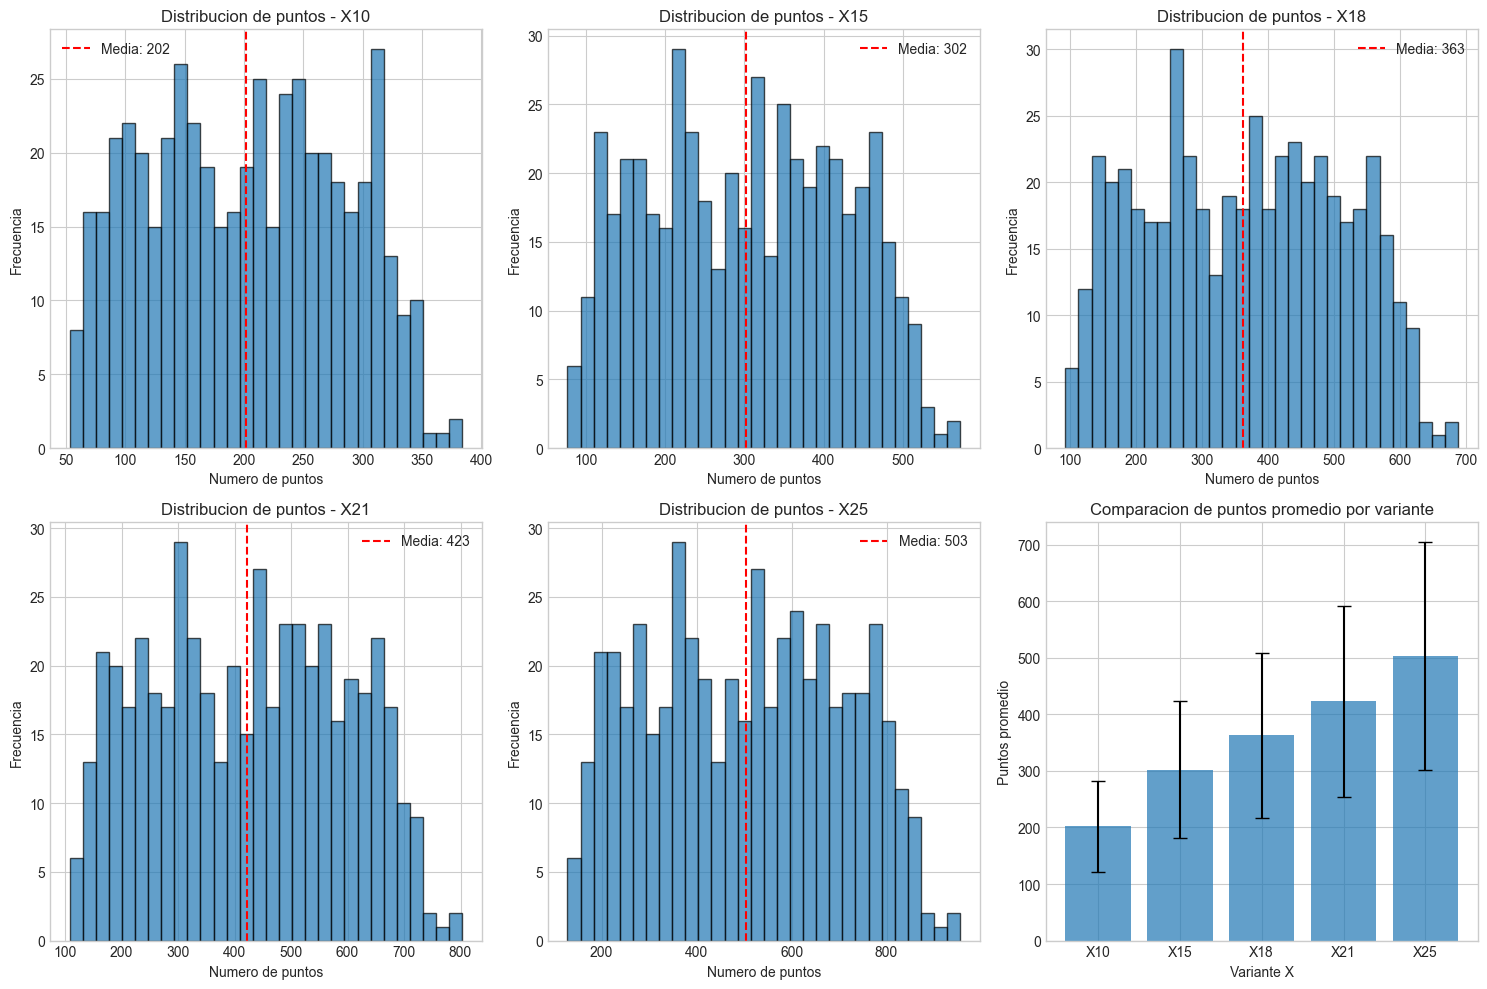

In [15]:
# Visualizacion de distribucion de puntos
fig, axes = plt.subplots(2, 3, figsize=(15, 10))

# Histograma para cada variante X
for idx, x_val in enumerate(sorted(pixel_lines_by_x.keys())):
    ax = axes[idx // 3, idx % 3]
    lines = pixel_lines_by_x[x_val]
    ax.hist(lines, bins=30, edgecolor='black', alpha=0.7)
    ax.set_title(f'Distribucion de puntos - X{x_val}')
    ax.set_xlabel('Numero de puntos')
    ax.set_ylabel('Frecuencia')
    ax.axvline(np.mean(lines), color='red', linestyle='--', label=f'Media: {np.mean(lines):.0f}')
    ax.legend()

# Grafico adicional: comparacion de medias
ax = axes[1, 2]
x_vals = sorted(pixel_lines_by_x.keys())
means = [np.mean(pixel_lines_by_x[x]) for x in x_vals]
stds = [np.std(pixel_lines_by_x[x]) for x in x_vals]
ax.bar(range(len(x_vals)), means, yerr=stds, capsize=5, alpha=0.7)
ax.set_xticks(range(len(x_vals)))
ax.set_xticklabels([f'X{x}' for x in x_vals])
ax.set_title('Comparacion de puntos promedio por variante')
ax.set_xlabel('Variante X')
ax.set_ylabel('Puntos promedio')

plt.tight_layout()
plt.savefig('distribucion_puntos.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 6. Verificacion de Integridad

In [16]:
print("VERIFICACION DE INTEGRIDAD DE DATOS")
print("=" * 60)

# Verificar archivos vacios
print("\n--- Archivos vacios")
empty_target = [f for f in target_files if f.stat().st_size == 0]
empty_pixel = [f for f in pixel_files if f.stat().st_size == 0]

print(f"Archivos vacios en target/: {len(empty_target)}")
print(f"Archivos vacios en pixel_curves/: {len(empty_pixel)}")

if empty_target:
    print(f"  Target vacios: {[f.name for f in empty_target[:5]]}")
if empty_pixel:
    print(f"  Pixel vacios: {[f.name for f in empty_pixel[:5]]}")

VERIFICACION DE INTEGRIDAD DE DATOS

--- Archivos vacios
Archivos vacios en target/: 0
Archivos vacios en pixel_curves/: 0


In [17]:
# Verificar valores numericos validos
print("\n--- Verificacion de valores numericos")

def check_numeric_values(filepath, sep):
    """Verifica que todos los valores sean numericos validos."""
    issues = []
    with open(filepath, 'r') as f:
        for i, line in enumerate(f, 1):
            line = line.strip()
            if not line:
                continue
            parts = line.split(sep)
            for j, part in enumerate(parts):
                try:
                    float(part)
                except ValueError:
                    issues.append(f"Linea {i}, Col {j+1}: '{part}' no es numerico")
            if len(issues) >= 5:
                break
    return issues

# Verificar muestra de archivos
print("\nVerificando valores numericos en target (muestra de 100):")
numeric_issues_target = 0
for f in list(target_files)[:100]:
    issues = check_numeric_values(f, ',')
    if issues:
        numeric_issues_target += 1
        print(f"  {f.name}: {issues[0]}")
print(f"  Archivos con valores no numericos: {numeric_issues_target}/100")

print("\nVerificando valores numericos en pixel_curves (muestra de 100):")
numeric_issues_pixel = 0
for f in list(pixel_files)[:100]:
    issues = check_numeric_values(f, ' ')
    if issues:
        numeric_issues_pixel += 1
        print(f"  {f.name}: {issues[0]}")
print(f"  Archivos con valores no numericos: {numeric_issues_pixel}/100")


--- Verificacion de valores numericos

Verificando valores numericos en target (muestra de 100):
  Archivos con valores no numericos: 0/100

Verificando valores numericos en pixel_curves (muestra de 100):
  Archivos con valores no numericos: 0/100


In [18]:
# Verificar valores NaN o infinitos
print("\n--- Verificacion de NaN e Infinitos")

def check_special_values(filepath, sep):
    """Busca NaN, Inf, -Inf en los datos."""
    special_count = {'nan': 0, 'inf': 0, '-inf': 0}
    with open(filepath, 'r') as f:
        for line in f:
            line = line.strip().lower()
            if 'nan' in line:
                special_count['nan'] += 1
            if 'inf' in line and '-inf' not in line:
                special_count['inf'] += 1
            if '-inf' in line:
                special_count['-inf'] += 1
    return special_count

total_special = {'nan': 0, 'inf': 0, '-inf': 0}

for f in target_files:
    counts = check_special_values(f, ',')
    for k, v in counts.items():
        total_special[k] += v

for f in pixel_files:
    counts = check_special_values(f, ' ')
    for k, v in counts.items():
        total_special[k] += v

print(f"\nValores especiales encontrados en todo el dataset:")
print(f"  NaN: {total_special['nan']}")
print(f"  Inf: {total_special['inf']}")
print(f"  -Inf: {total_special['-inf']}")


--- Verificacion de NaN e Infinitos

Valores especiales encontrados en todo el dataset:
  NaN: 0
  Inf: 0
  -Inf: 0


In [19]:
# Resumen final de integridad
print("\n" + "=" * 60)
print("RESUMEN DE INTEGRIDAD")
print("=" * 60)

checks = [
    ("Correspondencia target-pixel_curves", len(matching_ids) == len(curve_ids_pixel) == len(curve_ids_target)),
    ("Nomenclatura de archivos", len(invalid_pixel_files) == 0 and len(invalid_target_files) == 0),
    ("Completitud de variantes X", len(missing_variants) == 0),
    ("Sin archivos vacios", len(empty_target) == 0 and len(empty_pixel) == 0),
    ("Valores numericos validos", numeric_issues_target == 0 and numeric_issues_pixel == 0),
    ("Sin valores especiales (NaN/Inf)", sum(total_special.values()) == 0)
]

print("\nResultados de verificacion:")
for check_name, passed in checks:
    status = "[OK]" if passed else "[FALLO]"
    print(f"  {status} {check_name}")

total_passed = sum(1 for _, passed in checks if passed)
print(f"\nVerificaciones pasadas: {total_passed}/{len(checks)}")


RESUMEN DE INTEGRIDAD

Resultados de verificacion:
  [OK] Correspondencia target-pixel_curves
  [OK] Nomenclatura de archivos
  [OK] Completitud de variantes X
  [OK] Sin archivos vacios
  [OK] Valores numericos validos
  [OK] Sin valores especiales (NaN/Inf)

Verificaciones pasadas: 6/6


---
## Conclusiones de Estructura General

### Hallazgos Clave:

1. **Estructura del Dataset:**
   - 500 curvas unicas (IDs 0001-0500)
   - Cada curva tiene 1 version target (alta precision) y 5 versiones pixelizadas (X10, X15, X18, X21, X25)
   - Total: 3,000 archivos (500 target + 2,500 pixel_curves)

2. **Formato de Datos:**
   - Target: coordenadas flotantes separadas por coma (X,Y)
   - Pixel_curves: coordenadas enteras separadas por espacio (X Y)

3. **Consistencia:**
   - Todos los archivos target tienen 8,000 puntos
   - Los archivos pixel_curves varian en numero de puntos segun la resolucion X
   - Mayor X = mas puntos (mayor resolucion)

4. **Parametro X:**
   - X10: ~250-350 puntos
   - X15: ~350-520 puntos
   - X18: ~420-620 puntos
   - X21: ~500-720 puntos
   - X25: ~600-860 puntos